also installing the dependencies ‘plotrix’, ‘plotmo’


Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done

Loading required package: Formula

Loading required package: plotmo

Loading required package: plotrix



Call: earth(formula=y~x1+x2+x3, data=train_data, degree=2, nk=10)

              coefficients
(Intercept)       8.139099
h(x2-2.25073)    11.149391
h(5.33765-x2)    -3.823291
h(x2-5.33765)    16.095196
h(x2-7.84575)     8.792451
h(6.87743-x3)     1.711318

Selected 6 of 7 terms, and 2 of 3 predictors
Termination condition: Reached nk 10
Importance: x2, x3, x1-unused
Number of terms at each degree of interaction: 1 5 (additive model)
GCV 9.900898    RSS 1328.097    GRSq 0.9972919    RSq 0.997701

   nsubsets   gcv    rss
x2        5 100.0  100.0
x3        3   8.4    8.3

RMSE na testovacích dátach: 2.94452 


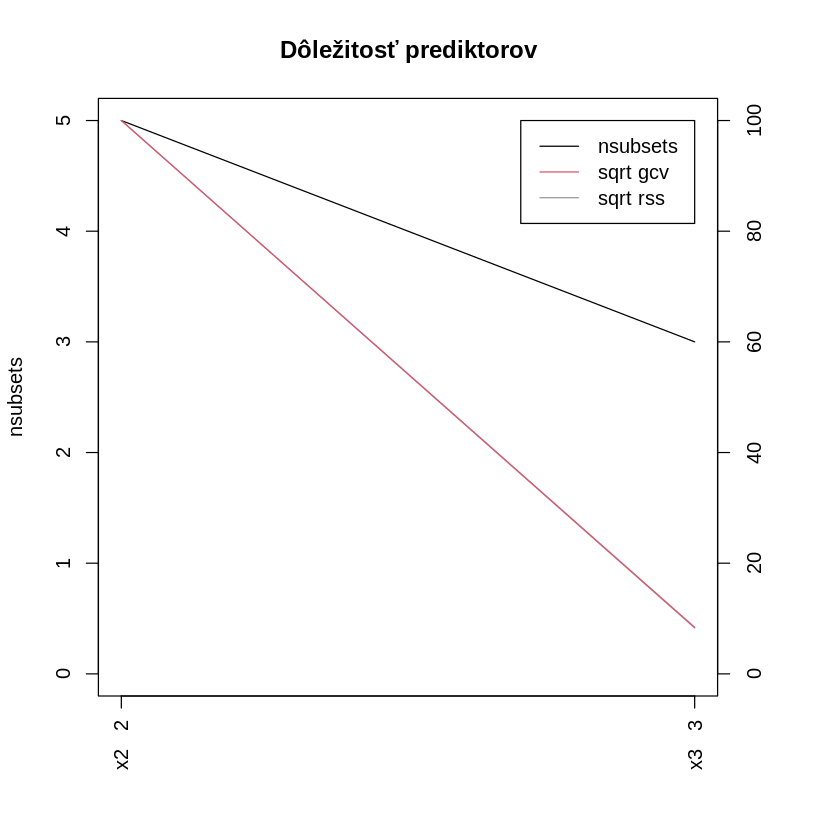

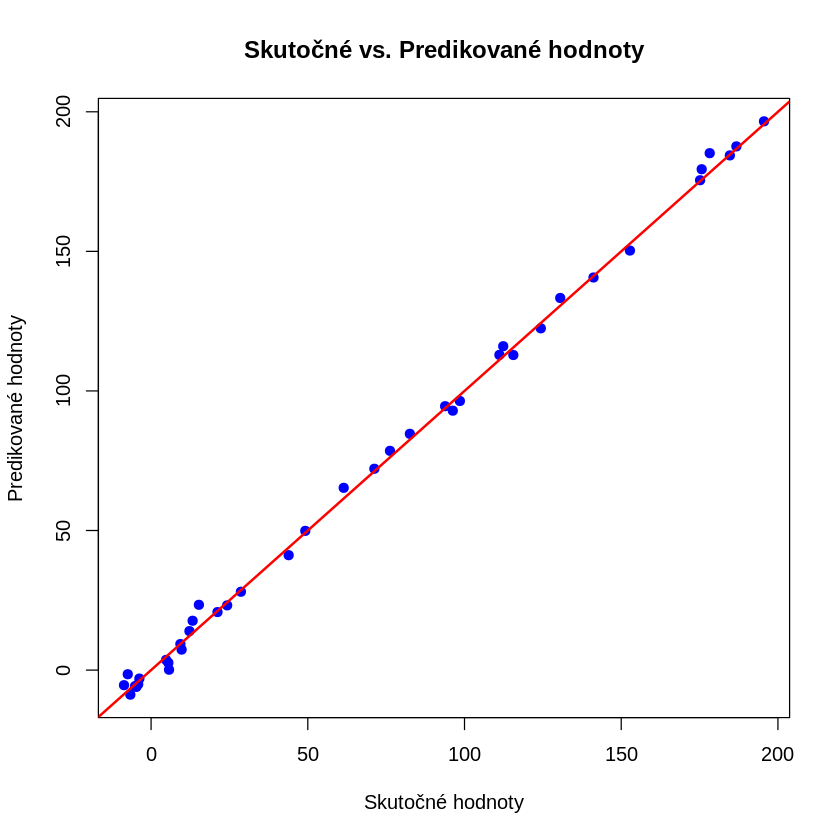

In [1]:
# Inštalácia potrebného balíka
if (!requireNamespace("earth", quietly = TRUE)) {
  install.packages("earth")
}
library(earth)

# Generovanie syntetických dát
set.seed(123) # Pre reprodukovateľnosť
n <- 200 # Počet vzoriek
x1 <- runif(n, 0, 10)
x2 <- runif(n, 0, 10)
x3 <- runif(n, 0, 10)
y <- 3 * sin(x1) + 2 * x2^2 - 1.5 * x3 + rnorm(n, 0, 2) # Nelinárna závislosť + šum

# Tvorba dátového rámca
data <- data.frame(x1, x2, x3, y)

# Rozdelenie dát na trénovaciu a testovaciu množinu (80 % trénovanie, 20 % test)
set.seed(456)
train_idx <- sample(seq_len(n), size = 0.8 * n)
train_data <- data[train_idx, ]
test_data <- data[-train_idx, ]

# Trénovanie MARS modelu pomocou balíka earth
mars_model <- earth(y ~ x1 + x2 + x3, data = train_data, degree = 2, nk = 10)

# Súhrn modelu
summary(mars_model)

# Vizualizácia dôležitosti prediktorov
evimp(mars_model) # Hodnotenie významnosti prediktorov
plot(evimp(mars_model), main = "Dôležitosť prediktorov")

# Predikcia na testovacích dátach
predictions <- predict(mars_model, newdata = test_data)

# Vyhodnotenie modelu
actual <- test_data$y
rmse <- sqrt(mean((actual - predictions)^2)) # Root Mean Squared Error (RMSE)
cat("RMSE na testovacích dátach:", rmse, "\n")

# Vizualizácia skutočných vs. predikovaných hodnôt
plot(actual, predictions, 
     main = "Skutočné vs. Predikované hodnoty",
     xlab = "Skutočné hodnoty", 
     ylab = "Predikované hodnoty",
     col = "blue", pch = 19)
abline(0, 1, col = "red", lwd = 2) # Ideálna línia y = x
